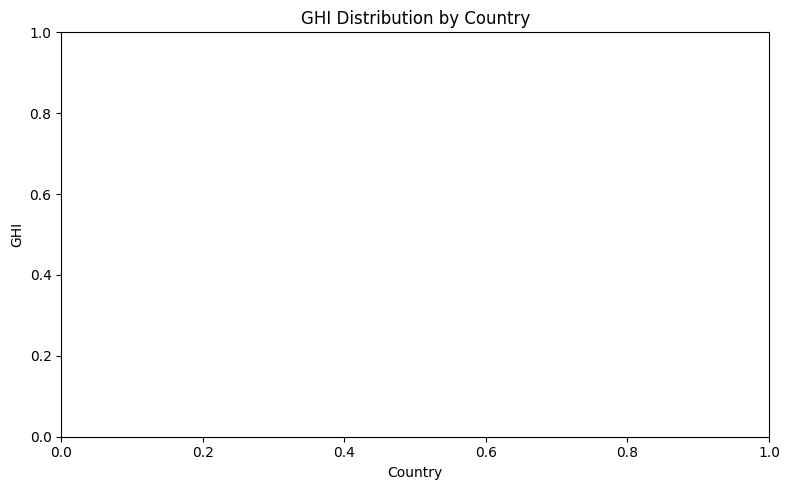

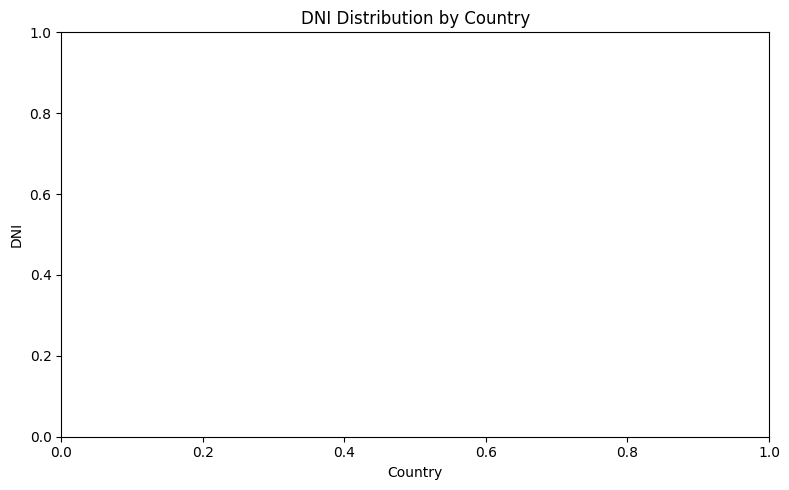

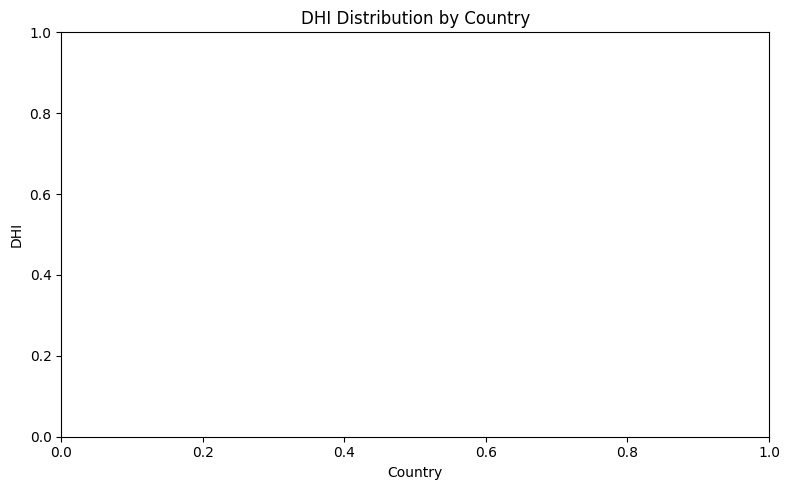

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal


# Load datasets
benin = pd.read_csv('data/benin_clean.csv')
sierra_leone = pd.read_csv('data/sierraleon_clean.csv')
togo = pd.read_csv('data/togo_clean.csv')

# Add country column
benin['Country'] = 'Benin'
sierra_leone['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'


# Combine
df_all = pd.concat([benin, sierra_leone, togo], ignore_index=True)

metrics = ['GHI', 'DNI', 'DHI']
# Boxplots: GHI, DNI, DHI by Country
for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Country', y=metric, data=df_all)
    plt.title(f"{metric} Distribution by Country")
    plt.ylabel(metric)
    plt.xlabel("Country")
    plt.tight_layout()
    plt.show()


In [139]:

#Summary Statistics Table
summary = df_all.groupby('Country')[['GHI', 'DNI', 'DHI']].agg(['mean', 'median', 'std'])
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary

,Country,GHI_mean,GHI_median,GHI_std,DNI_mean,DNI_median,DNI_std,DHI_mean,DHI_median,DHI_std


In [140]:
#Statistical Testing (ANOVA or Kruskal–Wallis)
ghi_benin = benin['GHI'].dropna()
ghi_sierra = sierra_leone['GHI'].dropna()
ghi_togo = togo['GHI'].dropna()
print("Benin GHI size:", len(ghi_benin))
print("Sierra Leone GHI size:", len(ghi_sierra))
print("Togo GHI size:", len(ghi_togo))

print("Missing GHI values:")
print("Benin:", benin['GHI'].isna().sum())
print("Sierra Leone:", sierra_leone['GHI'].isna().sum())
print("Togo:", togo['GHI'].isna().sum())


# Reassign after imputation or fix
ghi_benin = benin['GHI'].dropna()
ghi_sierra = sierra_leone['GHI'].dropna()
ghi_togo = togo['GHI'].dropna()

# Now run the test again
from scipy.stats import kruskal
stat, p = kruskal(ghi_benin, ghi_sierra, ghi_togo)

print(f"Kruskal-Wallis Test: H-statistic = {stat:.4f}, p-value = {p:.4f}")



Benin GHI size: 0
Sierra Leone GHI size: 0
Togo GHI size: 0
Missing GHI values:
Benin: 0
Sierra Leone: 0
Togo: 0
Kruskal-Wallis Test: H-statistic = nan, p-value = nan


C:\Users\michael\AppData\Local\Temp\ipykernel_16300\273909260.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(ghi_benin, ghi_sierra, ghi_togo)
